In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

/Users/anaconda3/envs/python_course/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


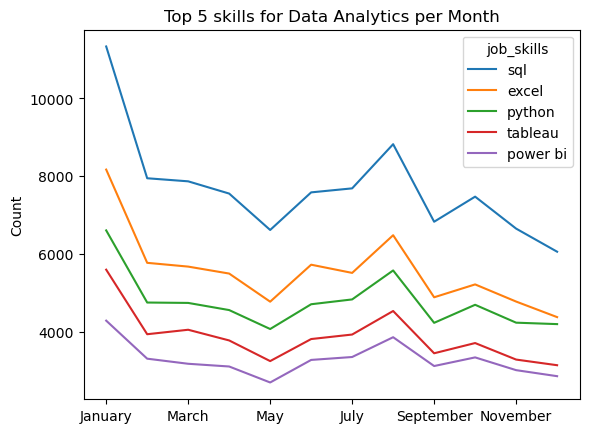

In [2]:

df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month
df_DA_explode = df_DA.explode('job_skills')
df_DA_pivot = df_DA_explode.pivot_table(index = 'job_posted_month_no', columns = 'job_skills', aggfunc = 'size', fill_value = 0)

df_DA_pivot.loc['Total'] = df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending = False).index]
df_DA_pivot = df_DA_pivot.drop('Total')

df_DA_pivot = df_DA_pivot = df_DA_pivot.reset_index()
df_DA_pivot['job_posted_month'] = df_DA_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%B'))
df_DA_pivot = df_DA_pivot.set_index('job_posted_month')
df_DA_pivot = df_DA_pivot.drop(columns='job_posted_month_no')

df_DA_pivot.iloc[:, :5].plot(kind = 'line')
    
plt.title('Top 5 skills for Data Analytics per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()



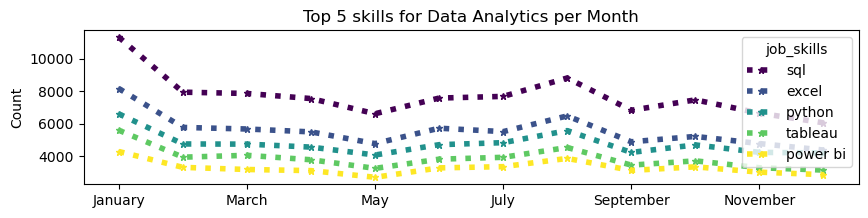

In [3]:
df_DA_pivot.iloc[:, :5].plot(
    kind = 'line',
    linewidth=4,
    linestyle=":",
    colormap='viridis',
    marker = '*',
    markersize = 5,
    figsize=(10,2)
    )
    
plt.title('Top 5 skills for Data Analytics per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

In [4]:
df_exploded = df_DA.explode('job_skills')

skill_stats = df_exploded.groupby('job_skills').agg(
    median_salary=('salary_year_avg', 'median'),
    skill_count=('job_skills', 'count')
)
skill_count = 20
skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(skill_count)

skill_stats


,median_salary,skill_count
job_skills,,
sql,92500.000000,92428
excel,84479.000000,66860
python,98500.000000,57190
tableau,95000.000000,46455
power bi,90000.000000,39380
r,92527.500000,29996
sas,90000.000000,27998
powerpoint,85000.000000,13822
word,80000.000000,13562


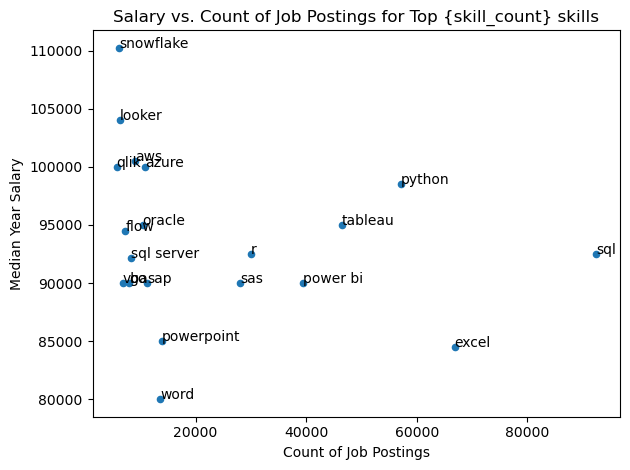

In [5]:
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')

for i, text in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], text)

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Year Salary')
plt.title('Salary vs. Count of Job Postings for Top {skill_count} skills')
plt.tight_layout()
plt.show()

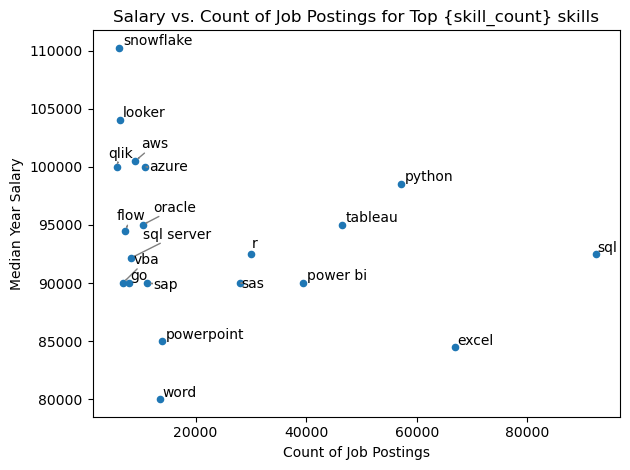

In [10]:
from adjustText import adjust_text

skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')

texts = []
for i, text in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], text))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='grey', lw=1))

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Year Salary')
plt.title('Salary vs. Count of Job Postings for Top {skill_count} skills')
plt.tight_layout()
plt.show()

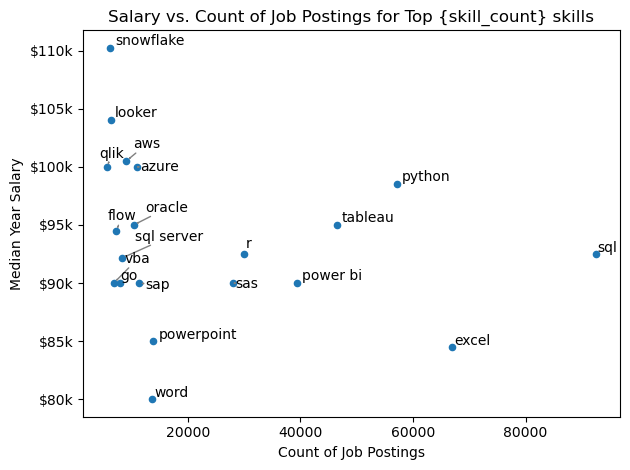

In [23]:

skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')

texts = []
for i, text in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], text))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='grey', lw=1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k'))

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Year Salary')
plt.title('Salary vs. Count of Job Postings for Top {skill_count} skills')
plt.tight_layout()
plt.show()